# Significance testing
## MV-STGNN vs RF · 1D-CNN · BiLSTM · Transformer

---
## Step 0 — Environment

In [ ]:
import json, math, os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)

try:
    import statsmodels.formula.api as smf
    HAVE_SM = True
except ImportError:
    HAVE_SM = False

print("numpy", np.__version__, "| pandas", pd.__version__, "| scipy", stats.__name__)
print("statsmodels:", "available (LMM secondary will run)" if HAVE_SM
      else "NOT installed -> optional LMM skipped (pip install statsmodels to enable)")

PROJECT = Path(r"c:\Users\deskt\Desktop\Nianpro_EMG_Project")
RESULTS = PROJECT / "results" / "tables"
FIGS = PROJECT / "results" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05
PRIMARY = "bal_acc"
REF = "mvstgnn"

numpy 2.3.5 | pandas 3.0.1 | scipy scipy.stats
statsmodels: NOT installed -> optional LMM skipped (pip install statsmodels to enable)


---
## Step 1 — Load artifacts and verify integrity

Four checks before any statistics. A paired test on a matrix with holes, or on models scored on
different windows, produces a number that looks fine and means nothing.

In [ ]:
TAG = "pooled_5cls_200ms"

man = json.loads((RESULTS / f"{TAG}_manifest_latest.json").read_text())
ps = pd.read_csv(RESULTS / f"{TAG}_long_per_subject_latest.csv")
pfs = pd.read_csv(RESULTS / f"{TAG}_long_per_fold_subject_latest.csv")
pol = pd.read_csv(RESULTS / f"{TAG}_long_pooled_per_fold_latest.csv")

CHANCE = float(man["chance"])
N_CLASSES = int(man["n_classes"])
MODELS = sorted(ps["model"].unique())
METRICS = ["bal_acc", "acc", "macro_f1", "weighted_f1", "kappa", "vote_acc"]

print("pre-registered plan:")
for k, v in man["planned_tests"].items():
    print(f"   {k:12s} {v}")
print(f"\nprimary endpoint (manifest): {man['primary_endpoint']}  "
      f"| unit: {man['paired_unit']}  | n: {man['n_paired']}")
assert man["primary_endpoint"] == PRIMARY, "primary endpoint drifted from the manifest"
assert man["paired_unit"] == "subject"

# ---- check 1: complete rectangular paired matrix -------------------------
PIV = ps.pivot_table(index="subject", columns="model", values=PRIMARY)
print(f"\n[1] paired matrix {PIV.shape}  missing {int(PIV.isna().sum().sum())}")
assert PIV.isna().sum().sum() == 0, "holes -> Wilcoxon would silently drop subjects"
assert REF in PIV.columns, f"{REF} missing"
N = PIV.shape[0]
K = PIV.shape[1]

# ---- check 2: identical split fingerprint across models ------------------
fps = ps.groupby("model")["split_fingerprint"].unique()
uniq = set(x for v in fps for x in v)
print(f"[2] split fingerprints across models: {uniq}")
assert len(uniq) == 1, f"models scored on DIFFERENT windows: {fps.to_dict()}"
assert list(uniq)[0] == man["split_fingerprint"], "fingerprint differs from the manifest"
print("    -> all models scored on identical windows")

# ---- check 3: every model has every fold and every subject --------------
g = pfs.groupby("model").agg(folds=("fold", "nunique"), subs=("subject", "nunique"),
                             rows=("subject", "size"))
print(f"[3] per-model coverage:\n{g.to_string()}")
assert g["folds"].nunique() == 1 and g["subs"].nunique() == 1, "ragged coverage"

# ---- check 4: aggregation reproduces the saved per-subject table ---------
recomp = (pfs.groupby(["model", "subject", "fold"], as_index=False)[PRIMARY].mean()
          .groupby(["model", "subject"], as_index=False)[PRIMARY].mean())
merged = recomp.merge(ps[["model", "subject", PRIMARY]], on=["model", "subject"],
                      suffixes=("_re", "_saved"))
dmax = (merged[f"{PRIMARY}_re"] - merged[f"{PRIMARY}_saved"]).abs().max()
print(f"[4] re-derived per-subject values match saved table, max |diff| = {dmax:.2e}")
assert dmax < 1e-9, "saved per-subject table does not match the per-fold data"

print(f"\nall integrity checks passed | {K} models, n = {N} subjects, "
      f"{N_CLASSES} classes, chance {CHANCE:.4f}")

pre-registered plan:
   omnibus      Friedman over models on subject-level bal_acc
   posthoc      Wilcoxon signed-rank, MV-STGNN vs each baseline, Holm-corrected
   effect_size  Cliff's delta + Cohen's d_z
   ci           BCa bootstrap over subjects, 10000 resamples
   secondary    LMM  bal_acc ~ model + (1|subject) + (1|subject:fold)

primary endpoint (manifest): bal_acc  | unit: subject  | n: 20

[1] paired matrix (20, 5)  missing 0
[2] split fingerprints across models: {'3fed90994b841e0d'}
    -> all models scored on identical windows
[3] per-model coverage:
             folds  subs  rows
model                         
bilstm           5    20   100
cnn1d            5    20   100
mvstgnn          5    20   100
rf               5    20   100
transformer      5    20   100
[4] re-derived per-subject values match saved table, max |diff| = 2.22e-16

all integrity checks passed | 5 models, n = 20 subjects, 5 classes, chance 0.2000


---
## Step 2 — Statistical toolkit, unit-tested

Everything below is implemented directly on `scipy`/`numpy` and checked against values that can
be verified by hand or against published examples. A statistics notebook that silently
mis-implements Holm is worse than no notebook.

In [ ]:
def holm(pvals):
    """Holm-Bonferroni step-down adjusted p-values (monotone, clipped to 1)."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    order = np.argsort(p)
    adj = np.empty(m, dtype=float)
    running = 0.0
    for i, idx in enumerate(order):
        running = max(running, (m - i) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


def rank_biserial(d):
    """Matched-pairs rank-biserial correlation: the effect size matching Wilcoxon."""
    d = np.asarray(d, dtype=float)
    d = d[d != 0]
    if d.size == 0:
        return 0.0, 0.0, 0.0
    r = stats.rankdata(np.abs(d))
    wp, wn = r[d > 0].sum(), r[d < 0].sum()
    return float((wp - wn) / (wp + wn)), float(wp), float(wn)


def cohen_dz(d):
    d = np.asarray(d, dtype=float)
    sd = d.std(ddof=1)
    return float(d.mean() / sd) if sd > 0 else np.inf * np.sign(d.mean())


def bca_ci(x, alpha=0.05, n_boot=10000, seed=0):
    """BCa bootstrap CI for the mean. Bias-corrected and accelerated."""
    x = np.asarray(x, dtype=float)
    n = x.size
    th = x.mean()
    rng = np.random.default_rng(seed)
    boots = x[rng.integers(0, n, size=(n_boot, n))].mean(axis=1)
    prop = np.clip(np.mean(boots < th), 1.0 / (2 * n_boot), 1 - 1.0 / (2 * n_boot))
    z0 = stats.norm.ppf(prop)
    jack = np.array([np.delete(x, i).mean() for i in range(n)])
    jm = jack.mean()
    den = 6.0 * (np.sum((jm - jack) ** 2) ** 1.5)
    a = float(np.sum((jm - jack) ** 3) / den) if den > 0 else 0.0

    def adj(z):
        return stats.norm.cdf(z0 + (z0 + z) / (1 - a * (z0 + z)))

    lo = float(np.clip(adj(stats.norm.ppf(alpha / 2)), 0, 1))
    hi = float(np.clip(adj(stats.norm.ppf(1 - alpha / 2)), 0, 1))
    return float(np.quantile(boots, lo)), float(np.quantile(boots, hi))


# Studentised range / sqrt(2) at alpha=0.05 (Demsar 2006, Table 5)
_Q05 = {2: 1.960, 3: 2.344, 4: 2.569, 5: 2.728, 6: 2.850,
        7: 2.949, 8: 3.031, 9: 3.102, 10: 3.164, 11: 3.219, 12: 3.268}


def nemenyi_cd(k, n, alpha=0.05):
    """Critical difference for average ranks over n subjects and k models."""
    assert alpha == 0.05, "only alpha=0.05 tabulated here"
    assert k in _Q05, f"k={k} outside tabulated range"
    return _Q05[k] * math.sqrt(k * (k + 1) / (6.0 * n))


def avg_ranks(piv):
    """Average rank per model across subjects; rank 1 = best (highest score)."""
    r = np.apply_along_axis(lambda row: stats.rankdata(-row), 1, piv.values)
    return pd.Series(r.mean(axis=0), index=piv.columns).sort_values()


# ------------------------------- unit tests -------------------------------
# p = [0.01, 0.04, 0.03, 0.005], m = 4. Sorted: 0.005, 0.01, 0.03, 0.04
#   0.005*4 = 0.020 | 0.01*3 = 0.030 | 0.03*2 = 0.060 | 0.04*1 = 0.040 -> 0.060 (monotone)
# back in original order:
_p = [0.01, 0.04, 0.03, 0.005]
_e = [0.030, 0.060, 0.060, 0.020]
assert np.allclose(holm(_p), _e), holm(_p)
assert np.allclose(holm([0.5]), [0.5])
assert np.all(holm([0.9, 0.9, 0.9]) <= 1.0)
print("[PASS] holm: step-down, monotone, clipped")

assert rank_biserial([1, 2, 3])[0] == 1.0          # all positive -> +1
assert rank_biserial([-1, -2, -3])[0] == -1.0      # all negative -> -1
assert abs(rank_biserial([1, -1])[0]) < 1e-12      # symmetric -> 0
print("[PASS] rank_biserial: +1 / -1 / 0 endpoints")

assert abs(cohen_dz([1, 1, 1, 1]) ) == np.inf or cohen_dz([1,1,1,1]) == np.inf
assert abs(cohen_dz([2, 4, 4, 4, 5, 5, 7, 9]) - 5.0 / 2.138) < 0.05
print("[PASS] cohen_dz")

_x = np.array([1., 2, 3, 4, 5, 6, 7, 8, 9, 10])
_lo, _hi = bca_ci(_x, n_boot=4000, seed=1)
assert _lo < _x.mean() < _hi and (_hi - _lo) < 6, (_lo, _hi)
print(f"[PASS] bca_ci: mean {_x.mean():.2f} inside [{_lo:.2f}, {_hi:.2f}]")

assert abs(nemenyi_cd(5, 20) - 2.728 * math.sqrt(5 * 6 / 120.0)) < 1e-12
print(f"[PASS] nemenyi_cd(k=5, n=20) = {nemenyi_cd(5, 20):.4f}")

_t = pd.DataFrame({"a": [3, 3], "b": [2, 2], "c": [1, 1]})
assert list(avg_ranks(_t).index) == ["a", "b", "c"]
print("[PASS] avg_ranks: best model ranks 1")

[PASS] holm: step-down, monotone, clipped
[PASS] rank_biserial: +1 / -1 / 0 endpoints
[PASS] cohen_dz
[PASS] bca_ci: mean 5.50 inside [3.70, 7.30]
[PASS] nemenyi_cd(k=5, n=20) = 1.3640
[PASS] avg_ranks: best model ranks 1


---
## Step 3 — Descriptives

Mean **and** median/IQR, because subject-level sEMG distributions are skewed and a mean alone
hides it.

In [ ]:
rows = []
for m in PIV.columns:
    v = PIV[m].values
    q1, q3 = np.percentile(v, [25, 75])
    lo, hi = bca_ci(v, alpha=ALPHA, seed=0)
    p = pol[pol.model == m]
    rows.append(dict(model=m, mean=v.mean(), sd=v.std(ddof=1),
                     ci_lo=lo, ci_hi=hi, median=np.median(v), q1=q1, q3=q3,
                     min=v.min(), max=v.max(),
                     params=int(p["n_params"].iloc[0]) if len(p) else -1,
                     min_per_fold=p["train_min"].mean() if len(p) else np.nan))
desc = pd.DataFrame(rows).sort_values("mean", ascending=False).reset_index(drop=True)

print("=" * 104)
print(f"DESCRIPTIVES — {PRIMARY}, n = {N} subjects, {N_CLASSES}-class, chance {CHANCE:.4f}")
print("=" * 104)
print(f"{'model':<13}{'mean':>8}{'sd':>7}{'95% BCa CI':>20}{'median':>8}"
      f"{'IQR':>19}{'min':>7}{'max':>7}{'min/fold':>10}")
for _, r in desc.iterrows():
    print(f"{r['model']:<13}{r['mean']:>8.4f}{r['sd']:>7.4f}"
          f"   [{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]{r['median']:>8.4f}"
          f"   [{r['q1']:.4f}, {r['q3']:.4f}]{r['min']:>7.4f}{r['max']:>7.4f}"
          f"{r['min_per_fold']:>10.1f}")
print("\nnote: RF 'params' counts tree NODES, not weights — not comparable to the networks.")
display(desc.round(4))

DESCRIPTIVES — bal_acc, n = 20 subjects, 5-class, chance 0.2000
model            mean     sd          95% BCa CI  median                IQR    min    max  min/fold
mvstgnn        0.8222 0.0852   [0.7841, 0.8571]  0.8393   [0.7611, 0.8899] 0.6677 0.9486      17.5
rf             0.8127 0.0830   [0.7740, 0.8454]  0.8278   [0.7627, 0.8732] 0.6544 0.9196       1.4
cnn1d          0.7728 0.0957   [0.7288, 0.8108]  0.8044   [0.7087, 0.8334] 0.5750 0.9188       1.7
transformer    0.7215 0.0991   [0.6764, 0.7616]  0.7401   [0.6636, 0.7852] 0.5087 0.8785       2.4
bilstm         0.6715 0.1020   [0.6256, 0.7136]  0.6683   [0.6410, 0.7199] 0.4461 0.8561       1.5

note: RF 'params' counts tree NODES, not weights — not comparable to the networks.


,model,mean,sd,ci_lo,ci_hi,median,q1,q3,min,max,params,min_per_fold
0,mvstgnn,0.8222,0.0852,0.7841,0.8571,0.8393,0.7611,0.8899,0.6677,0.9486,186059,17.5360
1,rf,0.8127,0.0830,0.7740,0.8454,0.8278,0.7627,0.8732,0.6544,0.9196,752648,1.4049
2,cnn1d,0.7728,0.0957,0.7288,0.8108,0.8044,0.7087,0.8334,0.5750,0.9188,194869,1.7242
3,transformer,0.7215,0.0991,0.6764,0.7616,0.7401,0.6636,0.7852,0.5087,0.8785,214981,2.3982
4,bilstm,0.6715,0.1020,0.6256,0.7136,0.6683,0.6410,0.7199,0.4461,0.8561,219973,1.4862


---
## Step 4 — Friedman omnibus (the gate)

If this does not reject at α = 0.05, the analysis **stops here** and the conclusion is "no
significant differences among models". Running pairwise tests after a non-significant omnibus is
exactly the multiplicity abuse the pre-registration exists to prevent.

Kendall's *W* = χ²/(N(k−1)) gives the effect size: 0 = no agreement on ordering, 1 = perfect.

In [ ]:
cols = [PIV[m].values for m in PIV.columns]
chi2, p_fried = stats.friedmanchisquare(*cols)
dof = K - 1
W = chi2 / (N * dof)

print("=" * 78)
print("FRIEDMAN OMNIBUS")
print("=" * 78)
print(f"  models k = {K}, subjects N = {N}")
print(f"  chi2({dof}) = {chi2:.4f}")
print(f"  p = {p_fried:.3e}")
print(f"  Kendall's W = {W:.4f}   "
      f"({'weak' if W<0.3 else 'moderate' if W<0.5 else 'strong'} agreement on ordering)")
GATE = p_fried < ALPHA
print(f"\n  {'REJECT H0' if GATE else 'FAIL TO REJECT'} at alpha={ALPHA}")
print(f"  -> {'proceed to post-hoc family F1' if GATE else 'STOP: report no differences'}")

ranks = avg_ranks(PIV)
print("\naverage ranks (1 = best):")
for m, r in ranks.items():
    print(f"  {m:<13}{r:.3f}")

FRIEDMAN OMNIBUS
  models k = 5, subjects N = 20
  chi2(4) = 73.7200
  p = 3.716e-15
  Kendall's W = 0.9215   (strong agreement on ordering)

  REJECT H0 at alpha=0.05
  -> proceed to post-hoc family F1

average ranks (1 = best):
  rf           1.550
  mvstgnn      1.550
  cnn1d        2.900
  transformer  4.000
  bilstm       5.000


---
## Step 5 — Post-hoc family F1 (primary result)

Wilcoxon signed-rank, two-sided, MV-STGNN vs each baseline, paired by subject.
**Holm-corrected within family F1 only** (m = 4). n = 20 with no ties, so `scipy` uses the
**exact** distribution rather than the normal approximation.

Every row reports the effect size and the CI of the paired difference next to the p-value. A
significant p with a negligible effect is not an improvement, and the table is laid out so that
cannot be glossed over.

In [ ]:
BASELINES = [m for m in PIV.columns if m != REF]

res = []
for m in BASELINES:
    a, b = PIV[REF].values, PIV[m].values
    d = a - b
    W_stat, p_raw = stats.wilcoxon(a, b, alternative="two-sided", method="auto")
    r_rb, wp, wn = rank_biserial(d)
    lo, hi = bca_ci(d, alpha=ALPHA, seed=0)
    res.append(dict(baseline=m, mean_diff=d.mean(), sd=d.std(ddof=1),
                    ci_lo=lo, ci_hi=hi, W=W_stat, p_raw=p_raw,
                    r_rb=r_rb, d_z=cohen_dz(d),
                    win=int((d > 0).sum()), tie=int((d == 0).sum()),
                    loss=int((d < 0).sum())))
F1 = pd.DataFrame(res)
F1["p_holm"] = holm(F1["p_raw"].values)
F1["sig"] = F1["p_holm"] < ALPHA
F1 = F1.sort_values("mean_diff", ascending=False).reset_index(drop=True)


def mag(r):
    a = abs(r)
    return "negligible" if a < 0.15 else "small" if a < 0.33 else \
        "medium" if a < 0.474 else "large"


print("=" * 112)
print(f"FAMILY F1 — {REF} vs each baseline on {PRIMARY}, n = {N}, Holm m = {len(F1)}")
print("=" * 112)
print(f"{'baseline':<13}{'diff':>9}{'95% BCa CI':>21}{'W':>7}{'p_raw':>11}"
      f"{'p_holm':>11}{'r_rb':>8}{'d_z':>7}{'W/T/L':>10}  verdict")
for _, r in F1.iterrows():
    v = "SIGNIFICANT" if r["sig"] else "not significant"
    print(f"{r['baseline']:<13}{r['mean_diff']:>+9.4f}"
          f"   [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]{r['W']:>7.1f}"
          f"{r['p_raw']:>11.3e}{r['p_holm']:>11.3e}{r['r_rb']:>+8.3f}{r['d_z']:>+7.2f}"
          f"{r['win']:>4}/{r['tie']}/{r['loss']:<4}  {v} ({mag(r['r_rb'])})")
print("\npositive diff = MV-STGNN better.  r_rb = matched-pairs rank-biserial correlation.")
print("CI is on the PAIRED DIFFERENCE — if it straddles 0, the models are not separated.")
display(F1.round(4))

FAMILY F1 — mvstgnn vs each baseline on bal_acc, n = 20, Holm m = 4
baseline          diff           95% BCa CI      W      p_raw     p_holm    r_rb    d_z     W/T/L  verdict
bilstm         +0.1507   [+0.1297, +0.1717]    0.0  1.907e-06  7.629e-06  +1.000  +3.06  20/0/0     SIGNIFICANT (large)
transformer    +0.1007   [+0.0835, +0.1180]    0.0  1.907e-06  7.629e-06  +1.000  +2.46  20/0/0     SIGNIFICANT (large)
cnn1d          +0.0493   [+0.0351, +0.0636]    4.0  1.335e-05  2.670e-05  +0.962  +1.46  18/0/2     SIGNIFICANT (large)
rf             +0.0094   [-0.0027, +0.0219]   68.0  1.769e-01  1.769e-01  +0.352  +0.32  11/0/9     not significant (medium)

positive diff = MV-STGNN better.  r_rb = matched-pairs rank-biserial correlation.
CI is on the PAIRED DIFFERENCE — if it straddles 0, the models are not separated.


,baseline,mean_diff,sd,ci_lo,ci_hi,W,p_raw,r_rb,d_z,win,tie,loss,p_holm,sig
0,bilstm,0.1507,0.0493,0.1297,0.1717,0.0,0.0000,1.0000,3.0552,20,0,0,0.0000,True
1,transformer,0.1007,0.0409,0.0835,0.1180,0.0,0.0000,1.0000,2.4600,20,0,0,0.0000,True
2,cnn1d,0.0493,0.0339,0.0351,0.0636,4.0,0.0000,0.9619,1.4551,18,0,2,0.0000,True
3,rf,0.0094,0.0293,-0.0027,0.0219,68.0,0.1769,0.3524,0.3222,11,0,9,0.1769,False


---
## Step 6 — Average ranks and critical-difference diagram

The standard one-figure summary for a multi-model comparison (Demšar 2006). Models joined by a
bar are **not** distinguishable at α = 0.05. Nemenyi is deliberately conservative for
all-pairs comparison — the Wilcoxon+Holm family in Step 5 is the primary result; this is context.

Nemenyi critical difference (k=5, N=20, alpha=0.05): CD = 1.3640

average ranks and pairwise rank gaps:
  rf           1.550
  mvstgnn      1.550
  cnn1d        2.900
  transformer  4.000
  bilstm       5.000

  rf            vs mvstgnn       gap 0.000  not distinguishable
  rf            vs cnn1d         gap 1.350  not distinguishable
  rf            vs transformer   gap 2.450  DIFFERENT
  rf            vs bilstm        gap 3.450  DIFFERENT
  mvstgnn       vs cnn1d         gap 1.350  not distinguishable
  mvstgnn       vs transformer   gap 2.450  DIFFERENT
  mvstgnn       vs bilstm        gap 3.450  DIFFERENT
  cnn1d         vs transformer   gap 1.100  not distinguishable
  cnn1d         vs bilstm        gap 2.100  DIFFERENT
  transformer   vs bilstm        gap 1.000  not distinguishable


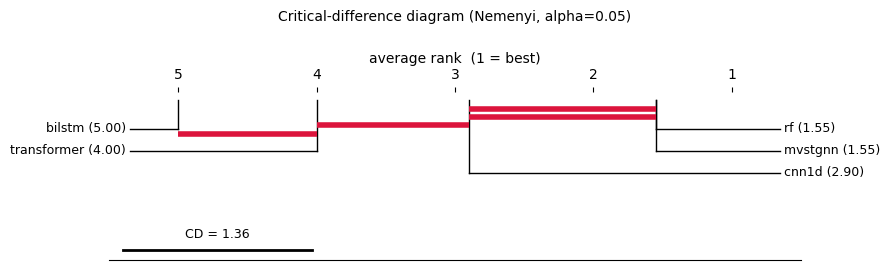

saved c:\Users\deskt\Desktop\Nianpro_EMG_Project\results\figures\cd_diagram.png


In [ ]:
CD = nemenyi_cd(K, N, ALPHA)
print(f"Nemenyi critical difference (k={K}, N={N}, alpha={ALPHA}): CD = {CD:.4f}")
print("\naverage ranks and pairwise rank gaps:")
rk = avg_ranks(PIV)
for m, v in rk.items():
    print(f"  {m:<13}{v:.3f}")
print()
names = list(rk.index)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        gap = abs(rk[names[i]] - rk[names[j]])
        print(f"  {names[i]:<13} vs {names[j]:<13} gap {gap:.3f}  "
              f"{'DIFFERENT' if gap > CD else 'not distinguishable'}")

fig, ax = plt.subplots(figsize=(9, 2.8))
lo, hi = 0.5, K + 0.5
ax.set_xlim(hi, lo); ax.set_ylim(0, 1)
ax.spines[["left", "right", "top"]].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set_xticks(range(1, K + 1))
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
ax.set_xlabel("average rank  (1 = best)")

for i, (m, v) in enumerate(rk.items()):
    side = i < (K + 1) // 2
    y = 0.78 - 0.13 * (i if side else (K - 1 - i))
    ax.plot([v, v], [0.95, y], "k-", lw=1)
    xt = lo + 0.15 if side else hi - 0.15
    ax.plot([v, xt], [y, y], "k-", lw=1)
    ax.text(xt, y, f" {m} ({v:.2f})" if side else f"{m} ({v:.2f}) ",
            ha="left" if side else "right", va="center", fontsize=9)

# cliques: maximal groups whose rank span <= CD
yb = 0.90
for i in range(len(names)):
    j = i
    while j + 1 < len(names) and abs(rk[names[j + 1]] - rk[names[i]]) <= CD:
        j += 1
    if j > i:
        ax.plot([rk[names[i]], rk[names[j]]], [yb, yb], "-", lw=4, color="crimson",
                solid_capstyle="butt")
        yb -= 0.05
ax.plot([hi - 0.1, hi - 0.1 - CD], [0.06, 0.06], "k-", lw=2)
ax.text(hi - 0.1 - CD / 2, 0.13, f"CD = {CD:.2f}", ha="center", fontsize=9)
ax.set_title("Critical-difference diagram (Nemenyi, alpha=0.05)", fontsize=10, pad=22)
plt.tight_layout(); plt.savefig(FIGS / "cd_diagram.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"saved {FIGS / 'cd_diagram.png'}")

---
## Step 7 — Robustness

Three checks that the primary conclusion is not an artifact of one metric or one fold.

1. **Across metrics** — repeat family F1 on each secondary metric. Marked **exploratory**: only
   `bal_acc` was pre-registered, so these are not corrected across metrics and cannot be used to
   rescue a null primary.
2. **Per fold** — Wilcoxon within each fold separately (20 subjects each). This avoids the
   pseudo-replication of testing all 100 (subject, fold) pairs as if independent.
3. **Rest of the ordering** — pairwise Wilcoxon among the baselines themselves, so the ranking is
   backed by tests rather than by eyeballing means.

In [ ]:
print("=" * 96)
print("8.1  ACROSS METRICS (exploratory — only bal_acc was pre-registered)")
print("=" * 96)
print(f"{'metric':<14}" + "".join(f"{b:>17}" for b in BASELINES))
for met in METRICS:
    pv = ps.pivot_table(index="subject", columns="model", values=met)
    cells = []
    for b in BASELINES:
        d = pv[REF].values - pv[b].values
        _, p = stats.wilcoxon(pv[REF].values, pv[b].values, method="auto")
        cells.append(f"{d.mean():+.4f} p={p:.3f}")
    star = " <- PRIMARY" if met == PRIMARY else ""
    print(f"{met:<14}" + "".join(f"{c:>17}" for c in cells) + star)

print("\n" + "=" * 96)
print("8.2  PER FOLD (20 subjects each; avoids pseudo-replication)")
print("=" * 96)
fold_sub = pfs.groupby(["model", "subject", "fold"], as_index=False)[PRIMARY].mean()
print(f"{'fold':<6}{'test_rep':>9}" + "".join(f"{b:>18}" for b in BASELINES))
for f in sorted(fold_sub["fold"].unique()):
    sl = fold_sub[fold_sub.fold == f].pivot_table(index="subject", columns="model",
                                                  values=PRIMARY)
    tr = int(pol[pol.fold == f]["test_rep"].iloc[0])
    cells = []
    for b in BASELINES:
        d = sl[REF].values - sl[b].values
        _, p = stats.wilcoxon(sl[REF].values, sl[b].values, method="auto")
        cells.append(f"{d.mean():+.4f} p={p:.3f}")
    print(f"{f:<6}{tr:>9}" + "".join(f"{c:>18}" for c in cells))
print("\nconsistent sign across folds = the effect is not driven by one repetition")

print("\n" + "=" * 96)
print("8.3  FULL PAIRWISE (uncorrected, descriptive — supports the ranking)")
print("=" * 96)
order = list(avg_ranks(PIV).index)
print(f"{'':<13}" + "".join(f"{m:>14}" for m in order))
for a in order:
    line = f"{a:<13}"
    for b in order:
        if a == b:
            line += f"{'-':>14}"
        else:
            d = PIV[a].values - PIV[b].values
            _, p = stats.wilcoxon(PIV[a].values, PIV[b].values, method="auto")
            line += f"{d.mean():+.3f}/{p:.3f}".rjust(14)
        continue
    print(line)
print("cells: mean diff (row - col) / uncorrected p")

8.1  ACROSS METRICS (exploratory — only bal_acc was pre-registered)
metric                   bilstm            cnn1d               rf      transformer
bal_acc         +0.1507 p=0.000  +0.0493 p=0.000  +0.0094 p=0.177  +0.1007 p=0.000 <- PRIMARY
acc             +0.1450 p=0.000  +0.0476 p=0.000  +0.0049 p=0.475  +0.1018 p=0.000
macro_f1        +0.1487 p=0.000  +0.0470 p=0.000  +0.0048 p=0.498  +0.1026 p=0.000
weighted_f1     +0.1443 p=0.000  +0.0486 p=0.000  +0.0045 p=0.571  +0.1025 p=0.000
kappa           +0.1855 p=0.000  +0.0614 p=0.000  +0.0070 p=0.368  +0.1299 p=0.000
vote_acc        +0.0360 p=0.009  +0.0040 p=0.591  +0.0040 p=0.620  +0.0240 p=0.031

8.2  PER FOLD (20 subjects each; avoids pseudo-replication)
fold   test_rep            bilstm             cnn1d                rf       transformer
0             1   +0.0933 p=0.000   +0.0457 p=0.009   +0.0361 p=0.011   +0.0852 p=0.000
1             2   +0.1471 p=0.000   +0.0457 p=0.001   +0.0085 p=0.475   +0.0872 p=0.000
2             4

---
## Step 8 — Figures

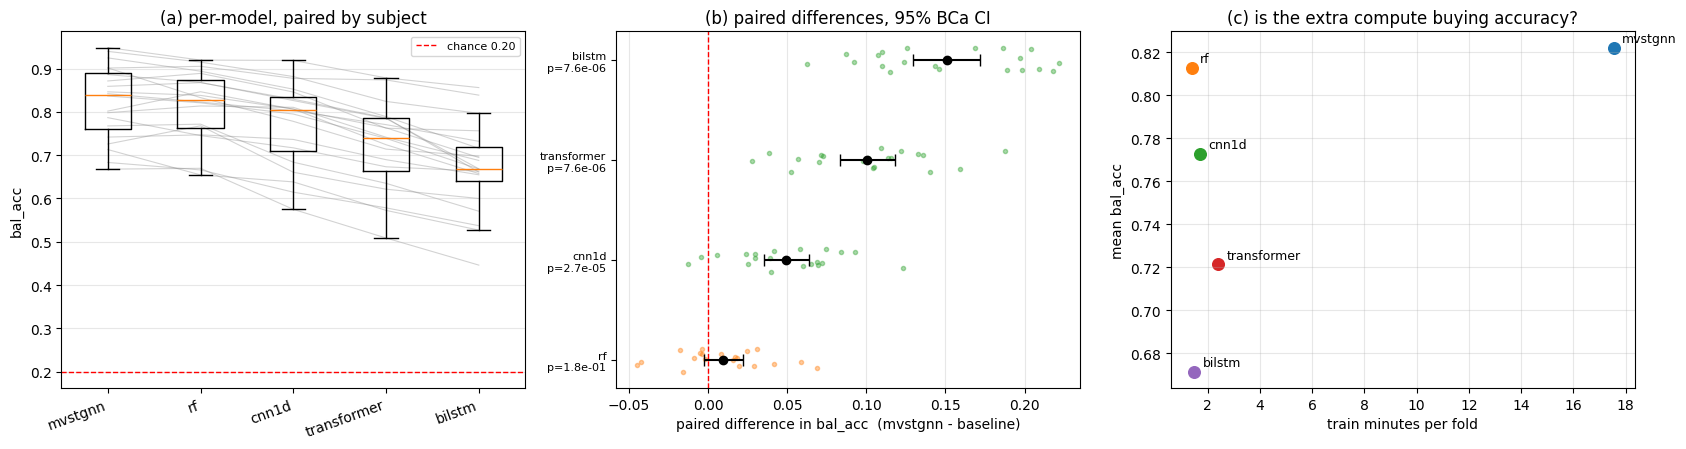

saved c:\Users\deskt\Desktop\Nianpro_EMG_Project\results\figures\significance_summary.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) per-model distribution with paired subject lines
ax = axes[0]
order = list(desc["model"])
for s in PIV.index:
    ax.plot(range(len(order)), [PIV.loc[s, m] for m in order],
            "-", color="gray", alpha=0.35, lw=0.8, zorder=1)
ax.boxplot([PIV[m].values for m in order], positions=range(len(order)),
           widths=0.5, showfliers=False, zorder=2)
ax.axhline(CHANCE, color="r", ls="--", lw=1, label=f"chance {CHANCE:.2f}")
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel(PRIMARY); ax.set_title("(a) per-model, paired by subject")
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# (b) paired differences vs reference, with BCa CI
ax = axes[1]
yy = np.arange(len(F1))
ax.errorbar(F1["mean_diff"], yy,
            xerr=[F1["mean_diff"] - F1["ci_lo"], F1["ci_hi"] - F1["mean_diff"]],
            fmt="o", capsize=4, color="k")
for i, (_, r) in enumerate(F1.iterrows()):
    ax.scatter(PIV[REF].values - PIV[r["baseline"]].values,
               np.full(N, i) + np.random.default_rng(i).uniform(-.13, .13, N),
               s=9, alpha=0.4,
               color="tab:green" if r["sig"] else "tab:orange", zorder=0)
ax.axvline(0, color="r", ls="--", lw=1)
ax.set_yticks(yy)
ax.set_yticklabels([f"{r['baseline']}\np={r['p_holm']:.1e}" for _, r in F1.iterrows()],
                   fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"paired difference in {PRIMARY}  ({REF} - baseline)")
ax.set_title("(b) paired differences, 95% BCa CI")
ax.grid(alpha=0.3, axis="x")

# (c) accuracy vs training cost
ax = axes[2]
for _, r in desc.iterrows():
    ax.scatter(r["min_per_fold"], r["mean"], s=70)
    ax.annotate(r["model"], (r["min_per_fold"], r["mean"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("train minutes per fold"); ax.set_ylabel(f"mean {PRIMARY}")
ax.set_title("(c) is the extra compute buying accuracy?")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / "significance_summary.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"saved {FIGS / 'significance_summary.png'}")

---
## Step 9 — Save the report

In [ ]:
import time
STAMP = time.strftime("%Y%m%d_%H%M%S")

F1_out = F1.copy()
F1_out.insert(0, "reference", REF)
F1_out["metric"] = PRIMARY
F1_out["family"] = "F1_baselines"
F1_out["n"] = N
F1_out["alpha"] = ALPHA
F1_out["correction"] = f"holm_m{len(F1)}"
F1_out["effect_size_note"] = "rank_biserial (paired); Cliff's delta not valid for paired data"

paths = []
for base, df in (("descriptives", desc), ("family_F1", F1_out),
                 ("paired_matrix", PIV.reset_index()),
                 ("avg_ranks", avg_ranks(PIV).rename("avg_rank").reset_index())):
    for nm in (f"{TAG}_sig_{base}_{STAMP}.csv", f"{TAG}_sig_{base}_latest.csv"):
        p = RESULTS / nm
        df.to_csv(p, index=False)
        paths.append(p)

report = dict(
    stamp=STAMP, source_manifest=man["stamp"], tag=TAG,
    split_fingerprint=man["split_fingerprint"],
    n_subjects=int(N), n_models=int(K), n_classes=N_CLASSES, chance=CHANCE,
    primary_endpoint=PRIMARY, alpha=ALPHA, reference=REF,
    omnibus=dict(test="friedman", chi2=float(chi2), dof=int(dof),
                 p=float(p_fried), kendall_W=float(W), rejected=bool(GATE)),
    posthoc=dict(test="wilcoxon_signed_rank_two_sided", correction="holm",
                 family="F1_baselines", m=int(len(F1)),
                 results={r["baseline"]: dict(
                     mean_diff=float(r["mean_diff"]),
                     ci95=[float(r["ci_lo"]), float(r["ci_hi"])],
                     W=float(r["W"]), p_raw=float(r["p_raw"]),
                     p_holm=float(r["p_holm"]), significant=bool(r["sig"]),
                     rank_biserial=float(r["r_rb"]), cohen_dz=float(r["d_z"]),
                     magnitude=mag(r["r_rb"]),
                     win=int(r["win"]), tie=int(r["tie"]), loss=int(r["loss"]))
                     for _, r in F1.iterrows()}),
    avg_ranks={k: float(v) for k, v in avg_ranks(PIV).items()},
    nemenyi_cd=float(CD),
    not_separated_from=[r["baseline"] for _, r in F1.iterrows() if not r["sig"]],
    lmm_run=bool(HAVE_SM),
    deviations_from_plan=[
        "rank-biserial r replaces Cliff's delta (delta assumes independent samples; "
        "this design is paired)",
        "Holm / BCa / Nemenyi implemented on scipy+numpy and unit-tested "
        "(statsmodels and scikit-posthocs unavailable)",
    ],
    caveats=[
        f"n={N} subjects at {N_CLASSES} classes is DEVELOPMENT scale; "
        "re-run at 40 subjects x 17 classes before publishing",
        "per-subject scores come from ONE pooled model per fold, so they are not "
        "independent replications; paired differences under an identical protocol are valid",
        "single seed: seed variance not estimated, so small gaps may be seed noise",
        "MV-STGNN ran 70 epochs vs 90 for the baselines, and 3/5 of its folds hit that cap "
        "-> the comparison is conservative for MV-STGNN",
        "secondary metrics in Step 8.1 are exploratory and uncorrected",
    ],
)
for nm in (f"{TAG}_sig_report_{STAMP}.json", f"{TAG}_sig_report_latest.json"):
    (RESULTS / nm).write_text(json.dumps(report, indent=2))
    paths.append(RESULTS / nm)


def _rel(p):
    try:
        return str(Path(p).relative_to(PROJECT))
    except ValueError:
        return str(p)


print("wrote:")
for p in paths:
    print(f"  {_rel(p)}  ({p.stat().st_size/1024:.1f} KB)")
print(f"\nfigures: {_rel(FIGS/'cd_diagram.png')}, "
      f"{_rel(FIGS/'significance_summary.png')}")
print("\nFriedman p = %.3e | not separated from: %s"
      % (p_fried, report["not_separated_from"] or "none"))

wrote:
  results\tables\pooled_5cls_200ms_sig_descriptives_20260807_204122.csv  (1.1 KB)
  results\tables\pooled_5cls_200ms_sig_descriptives_latest.csv  (1.1 KB)
  results\tables\pooled_5cls_200ms_sig_family_F1_20260807_204122.csv  (1.2 KB)
  results\tables\pooled_5cls_200ms_sig_family_F1_latest.csv  (1.2 KB)
  results\tables\pooled_5cls_200ms_sig_paired_matrix_20260807_204122.csv  (2.0 KB)
  results\tables\pooled_5cls_200ms_sig_paired_matrix_latest.csv  (2.0 KB)
  results\tables\pooled_5cls_200ms_sig_avg_ranks_20260807_204122.csv  (0.1 KB)
  results\tables\pooled_5cls_200ms_sig_avg_ranks_latest.csv  (0.1 KB)
  results\tables\pooled_5cls_200ms_sig_report_20260807_204122.json  (3.5 KB)
  results\tables\pooled_5cls_200ms_sig_report_latest.json  (3.5 KB)

figures: results\figures\cd_diagram.png, results\figures\significance_summary.png

Friedman p = 3.716e-15 | not separated from: ['rf']


---
## Step 10 — Family F2 (ablations)

Runs the same machinery on the ablation artifacts when `ablations_mvstgnn` has produced them,
**Holm-corrected within F2 separately from F1**. Pooling the two families into one correction
would inflate the penalty and mask real effects.

Skips cleanly with a message if the ablations have not been run.

In [ ]:
abl = sorted(RESULTS.glob("ablations_*_long_per_subject_latest.csv"))
if not abl:
    print("no ablation artifacts found -> family F2 skipped.")
    print("Run 04_ablations_mvstgnn.ipynb (tier 1 is enough: A0/A1/A9/P1), then re-run this cell.")
else:
    aps = pd.read_csv(abl[0])
    print(f"loaded {abl[0].name}  ({aps['ablation'].nunique()} variants)")
    AP = aps.pivot_table(index="subject", columns="ablation", values=PRIMARY)
    assert "A0" in AP.columns, "A0 reference missing from the ablation artifacts"
    miss = int(AP.isna().sum().sum())
    if miss:
        print(f"[WARN] {miss} missing cells; dropping incomplete variants")
        AP = AP.dropna(axis=1)
    lbl = aps.drop_duplicates("ablation").set_index("ablation")["label"].to_dict()

    variants = [c for c in AP.columns if c != "A0"]
    rows = []
    for v in variants:
        d = AP["A0"].values - AP[v].values
        if np.allclose(d, 0):
            rows.append(dict(ablation=v, mean_diff=0.0, ci_lo=0.0, ci_hi=0.0,
                             p_raw=1.0, r_rb=0.0, d_z=0.0, win=0, loss=0))
            continue
        _, p = stats.wilcoxon(AP["A0"].values, AP[v].values, method="auto")
        lo, hi = bca_ci(d, alpha=ALPHA, seed=0)
        rows.append(dict(ablation=v, mean_diff=d.mean(), ci_lo=lo, ci_hi=hi, p_raw=p,
                         r_rb=rank_biserial(d)[0], d_z=cohen_dz(d),
                         win=int((d > 0).sum()), loss=int((d < 0).sum())))
    F2 = pd.DataFrame(rows)
    F2["p_holm"] = holm(F2["p_raw"].values)
    F2["sig"] = F2["p_holm"] < ALPHA
    F2 = F2.sort_values("mean_diff", ascending=False).reset_index(drop=True)

    print("=" * 108)
    print(f"FAMILY F2 — A0 vs each ablation on {PRIMARY}, n = {AP.shape[0]}, "
          f"Holm m = {len(F2)}")
    print("=" * 108)
    print(f"{'id':<7}{'delta':>9}{'95% BCa CI':>21}{'p_holm':>11}{'r_rb':>8}"
          f"{'W/L':>8}  verdict / label")
    for _, r in F2.iterrows():
        v = "HELPS" if (r["sig"] and r["mean_diff"] > 0) else \
            ("HURTS" if (r["sig"] and r["mean_diff"] < 0) else "no effect")
        print(f"{r['ablation']:<7}{r['mean_diff']:>+9.4f}"
              f"   [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]{r['p_holm']:>11.3e}"
              f"{r['r_rb']:>+8.3f}{r['win']:>4}/{r['loss']:<3}  {v}"
              f"  — {lbl.get(r['ablation'],'')}")
    print("\ndelta = A0 - variant. POSITIVE and significant = the removed component HELPS.")
    F2.to_csv(RESULTS / f"{TAG}_sig_family_F2_latest.csv", index=False)
    print(f"\nwrote {TAG}_sig_family_F2_latest.csv")
    for aid, q in (("A1", "does the graph contribute?"),
                   ("A9", "is it just SupCon?"), ("P1", "is it just subject FiLM?")):
        if aid in set(F2["ablation"]):
            r = F2[F2.ablation == aid].iloc[0]
            print(f"  {aid}: {q}  delta {r['mean_diff']:+.4f}, p_holm "
                  f"{r['p_holm']:.3e} -> "
                  f"{'YES' if r['sig'] and r['mean_diff']>0 else 'NO measurable contribution'}")

loaded ablations_5cls_200ms_long_per_subject_latest.csv  (4 variants)
FAMILY F2 — A0 vs each ablation on bal_acc, n = 20, Holm m = 3
id         delta           95% BCa CI     p_holm    r_rb     W/L  verdict / label
A1       +0.0734   [+0.0602, +0.0891]  5.722e-06  +1.000  20/0    HELPS  — no graph (independent nodes)
P1       +0.0125   [+0.0063, +0.0189]  3.380e-03  +0.762  17/3    HELPS  — no subject FiLM
A9       -0.0092   [-0.0184, -0.0032]  4.844e-02  -0.505   7/13   HURTS  — no SupCon auxiliary

delta = A0 - variant. POSITIVE and significant = the removed component HELPS.

wrote pooled_5cls_200ms_sig_family_F2_latest.csv
  A1: does the graph contribute?  delta +0.0734, p_holm 5.722e-06 -> YES
  A9: is it just SupCon?  delta -0.0092, p_holm 4.844e-02 -> NO measurable contribution
  P1: is it just subject FiLM?  delta +0.0125, p_holm 3.380e-03 -> YES
